# 2. The arrival scan

The engine at the centre of Oroscope. This notebook shows *how* it works, because the
mechanism explains both what it costs and what it can and cannot tell you.

Trace a ray **backwards** from a candidate along an arrival direction — azimuth φ,
elevation θ. Rays above the local horizon escape to the sky. Rays below it strike
terrain, and that first intersection is where the tau left the rock.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from oroscope import arrival_scan
from oroscope import figures
from oroscope import site_searcher as ss

grid = ss.resolve_grid_geometry("no-such-file.tif", -15.6, cell_size_deg=1/3600)

## One walk fills every elevation bin

Writing the terrain's elevation angle at ground distance $d$ as

$$\theta_{\rm terrain}(d) = \arctan\!\left(\frac{z(d) - d^2/2R - z_0}{d}\right)$$

a ray at angle θ first meets terrain at the smallest $d$ where
$\theta_{\rm terrain}(d) \ge \theta$. Since the **running maximum** of
$\theta_{\rm terrain}$ only increases, each new maximum claims a contiguous band of
elevation bins — so one pass fills them all.

That is why elevation binning is nearly free and the **azimuth count** is what sets the
cost of a search.

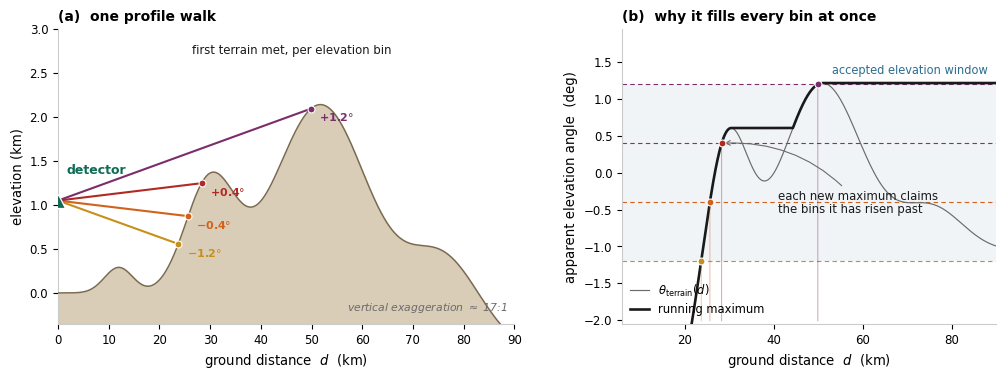

In [2]:
figures.walk_mechanism()
plt.show()

The $d^2/2R$ term is the Earth's curvature dropping distant ground below a straight
line. It uses the **true** Earth radius: the neutrino and the tau are not refracted.
Only the radio path gets the inflated 4/3 radius, and only for the Fresnel term.

In [3]:
for k in (1.0, 4/3):
    R = arrival_scan.earth_radius_for_k(k)
    drop = (80_000.0 ** 2) / (2 * R)
    print(f"k = {k:.2f}:  R = {R/1000:>6,.0f} km   drop over 80 km = {drop:5.0f} m")

k = 1.00:  R =  6,371 km   drop over 80 km =   502 m
k = 1.33:  R =  8,495 km   drop over 80 km =   377 m


## The ground at your own feet

A consequence that is easy to forget, and which broke four separate tests in this
project's history: **a detector standing on the ground has every steeply downward
direction blocked by the ground it stands on.**

On a uniform slope, a ray angled down more steeply than the slope intersects terrain
within a pixel or two.

In [4]:
# A plane sloping down toward the east at 20 degrees
n = 300
cols = np.arange(n)[None, :].repeat(n, 0)
slope_deg = 20.0
z_plane = (3000.0 - cols * grid.cell_size_x * np.tan(np.radians(slope_deg))).astype(np.float32)

cand = np.array([[150.0, 30.0, 90.0]])
r = arrival_scan.scan(cand, z_plane, grid, n_azimuths=1, half_width_deg=0.0,
                      use_aspect=True, elev_min_deg=-40.0, elev_max_deg=5.0,
                      n_elev_bins=45, min_dist_km=0.0, max_dist_km=6.0,
                      max_range_m=6000.0)
print(f"terrain slopes down at {slope_deg:.0f} deg")
print(f"horizon seen from the candidate: {r['horizon_deg'][0]:.1f} deg")
print(f"mean distance to first terrain: {r['mean_distance_m'][0]:,.0f} m")
print()
print("Rays steeper than the slope hit immediately; shallower ones never hit at all.")

terrain slopes down at 20 deg
horizon seen from the candidate: -20.0 deg
mean distance to first terrain: 30 m

Rays steeper than the slope hit immediately; shallower ones never hit at all.


## Column depth accumulates over the whole walk

The ray at angle θ is underground wherever $\theta_{\rm terrain}(d) > \theta$, so
binning the terrain angle and taking a suffix sum gives the underground path length for
every bin at once. Rays crossing several ridges accumulate **all** the rock they
traverse, not only the first chord.

There is a caveat worth knowing, and it is documented as a limitation: the walk stops at
`max_dist_km`, so for a short-range search the depth reported is bounded by how far is
left to walk rather than by the target's real thickness.

In [5]:
n = 400
cols = np.arange(n)[None, :].repeat(n, 0)
x_m = cols * grid.cell_size_x
z_two = (2000.0
         + 900.0 * np.exp(-((x_m - 4000.0) / 500.0) ** 2)
         + 1400.0 * np.exp(-((x_m - 9000.0) / 800.0) ** 2)).astype(np.float32)

cand = np.array([[200.0, 30.0, 90.0]])
for max_km in (6.0, 12.0, 20.0):
    r = arrival_scan.scan(cand, z_two, grid, n_azimuths=1, half_width_deg=0.0,
                          use_aspect=True, elev_min_deg=-3.0, elev_max_deg=3.0,
                          n_elev_bins=12, min_dist_km=1.0, max_dist_km=max_km,
                          max_range_m=max_km * 1000)
    print(f"walk to {max_km:>4.0f} km:  max depth {r['max_depth_gcm2'][0]:>12,.0f} g/cm^2   "
          f"cells {int(r['cells'][0]):>3}")

walk to    6 km:  max depth      718,227 g/cm^2   cells   6
walk to   12 km:  max depth    1,728,480 g/cm^2   cells   6
walk to   20 km:  max depth    1,728,480 g/cm^2   cells   6


## Azimuths are the cost

One profile walk per (candidate, azimuth), regardless of how finely the elevation
window is sampled. So doubling the elevation bins is nearly free; doubling the azimuths
is not.

In [6]:
import time

cands = np.column_stack([np.repeat(np.arange(50, 250), 20),
                         np.tile(np.arange(20, 40), 200),
                         np.full(4000, 90.0)]).astype(np.float64)

for n_az, n_bins in ((1, 12), (1, 48), (9, 12)):
    t = time.perf_counter()
    arrival_scan.scan(cands, z_two, grid, n_azimuths=n_az, half_width_deg=60.0,
                      elev_min_deg=-3.0, elev_max_deg=3.0, n_elev_bins=n_bins,
                      min_dist_km=1.0, max_dist_km=10.0, max_range_m=10000.0)
    dt = time.perf_counter() - t
    print(f"{n_az} azimuth(s), {n_bins:>2} bins: {dt*1000:7.1f} ms")

print()
print("Four times the bins costs almost nothing; nine times the azimuths costs nine times.")

1 azimuth(s), 12 bins:     6.6 ms
1 azimuth(s), 48 bins:     9.9 ms
9 azimuth(s), 12 bins:    33.2 ms

Four times the bins costs almost nothing; nine times the azimuths costs nine times.


*(The first timing includes JIT compilation, so read the relative numbers of the last
two rather than the absolute ones.)*

## Where to go next

- **[3. The physics toolkit](03_physics_toolkit.ipynb)** — what the geometry gets
  multiplied by.
- **[4. Criteria and scoring](04_criteria_and_scoring.ipynb)** — turning observables
  into a comparable number.

---

*Part of the [Oroscope](https://github.com/mbustama/oroscope) tutorials. Previous: [Getting started](01_getting_started.ipynb). Next: [The physics toolkit](03_physics_toolkit.ipynb). Full API reference: [oroscope docs](https://mbustama.github.io/oroscope/functions.html).*